<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Statistical-Data-Analysis-2/blob/master/LAB_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to task 1. Reparameterization Technique


In the Evidence Lower Bound (ELBO), the reconstruction term
$$
E_{z \sim q_\phi(z \mid x^{(i)})}
\big[
\log p(x^{(i)} \mid z, \mathbf{w})
\big]
$$
requires sampling from the variational posterior
$q_\phi(z \mid x^{(i)})$.

However, neural networks trained using gradient-based optimization methods
cannot propagate gradients through stochastic sampling operations.
Directly sampling
$$
z \sim q_\phi(z \mid x^{(i)})
$$
would therefore prevent gradient-based learning of the encoder parameters
$\boldsymbol{\phi}$.


---

### Key idea

The reparameterization trick expresses the random variable $z$ as a **deterministic**
function of:

- the input $x^{(i)}$,
- the encoder parameters $\phi$,
- and an auxiliary noise variable $\varepsilon$, independent of $\phi$.

Instead of sampling $z$ directly, we sample:

$$
\varepsilon \sim {N}(0, I),
$$

and define

$$
z = \mu_\phi(x^{(i)}) + \Sigma_\phi^{1/2}(x^{(i)}) \, \varepsilon.
$$

In practice, since the covariance matrix is assumed to be diagonal, this simplifies to:

$$
z = \mu_\phi(x^{(i)}) + \sigma_\phi(x^{(i)}) \odot \varepsilon,
$$

where $\odot$ denotes element-wise multiplication.

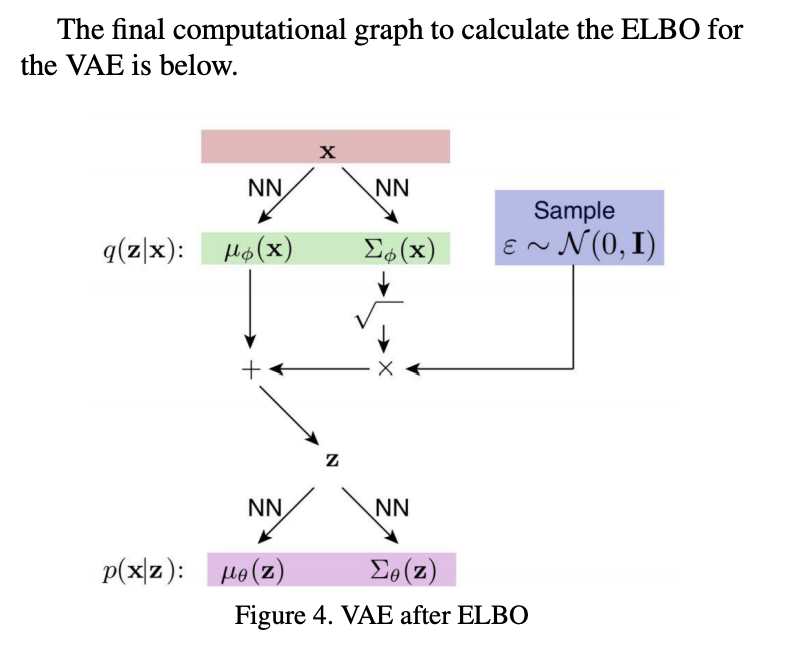

---

### Why this works

- $z$ is now a **deterministic transformation** of $\varepsilon$
- gradients can flow through $\mu_\phi(x)$ and $\sigma_\phi(x)$
- sampling occurs only in $\varepsilon$, which does not depend on model parameters

Thus, the resulting $z$ is still a valid sample from  
$q_\phi(z \mid x^{(i)})$, while backpropagation remains possible.

---

Adapted from: https://www.ericmfischer.com/project/variational-autoencoder/variational-autoencoder.pdf

### Consequence for ELBO optimization

After reparameterization, the ELBO can be written as:

$$
L(x^{(i)};\boldsymbol{\phi},\mathbf{w})
=
\mathbb{E}_{\varepsilon \sim N(0,I)}
\big[
\log p(x^{(i)} \mid z(\varepsilon, x^{(i)}), \mathbf{w})
\big]
-
\mathrm{KL}\big(q_\phi(z \mid x^{(i)})\,\|\,p(z)\big).
$$

which can now be optimized efficiently using standard stochastic gradient descent.

---

## Task 1

Implement a function that:

- takes as input the vectors  
  $\mu_\phi(x)$ and  $\log \sigma_\phi^2(x)$,

- generates an auxiliary noise variable  
  $ \varepsilon \sim N(0, I)$,

- computes a sample  
  $
  z \sim q_\phi(z \mid x)
  $
  using a deterministic transformation,

- ensures that gradients can flow through the entire operation.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        # Encoder q_phi(z | x)
        self.encoder_fc = nn.Linear(28 * 28, 400)
        self.encoder_mu = nn.Linear(400, latent_dim)        # μ_φ(x)
        self.encoder_logvar = nn.Linear(400, latent_dim)    # log σ_φ^2(x)

        # Decoder p_theta(x | z)
        self.decoder_fc = nn.Linear(latent_dim, 400)
        self.decoder_out = nn.Linear(400, 28 * 28)

    def encode(self, x):
        """
        Returns parameters of q_phi(z | x):
        μ_φ(x), log σ_φ^2(x)
        """
        h = F.relu(self.encoder_fc(x))
        mu = self.encoder_mu(h)
        log_var = self.encoder_logvar(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """
        z = μ_φ(x) + σ_φ(x) ⊙ ε
        where ε ~ N(0, I)
        """
        #@TODO
        std = (log_var * 0.5).exp()
        epsilon = torch.randn_like(std)

        z = mu + std * epsilon
        return z

    def decode(self, z):
        """
        Returns p_theta(x | z)
        """
        h = F.relu(self.decoder_fc(z))
        x_recon = torch.sigmoid(self.decoder_out(h))
        return x_recon

    def forward(self, x):
        """
        Full VAE forward pass:
        x -> μ_φ(x), log σ_φ^2(x) -> z -> x̂
        """
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_hat = self.decode(z)
        return x_hat, mu, log_var

## Task 2: Implementing the ELBO Loss (VAE)

In a Variational Autoencoder (VAE), the model is trained by maximizing the
Evidence Lower Bound (ELBO), defined as:

$
L(x;\boldsymbol{\phi},\mathbf{w})
=
\mathbb{E}_{z \sim q_\phi(z \mid x)}
\big[
\log p(x \mid z, \mathbf{w})
\big]
-
\mathrm{KL}\big(q_\phi(z \mid x)\,\|\,p(z)\big).
$

The ELBO consists of two components:

1. a reconstruction term
$
\mathbb{E}_{z \sim q_\phi(z \mid x)}
\big[
\log p(x \mid z, \mathbf{w})
\big],
$

2. a regularization term
$
\mathrm{KL}\big(q_\phi(z|x)\,\|\,p(z)\big)
$

Hint: Based on notes from practical tasks:
We have that the resulting expression takes the following form:
$$
\mathrm{KL}\big(q_\phi(z \mid x)\,\|\,p(z)\big).
$$

After implementation, please run the code to evaluate the quality of the latent space representation.

In [3]:
def elbo_loss(x, x_hat, mu, log_var):
    # Reconstruction term: E_q[log p(x | z)]
    recon_loss = F.binary_cross_entropy(
        x_hat, x, reduction='sum'
    )

    # KL divergence: KL(q_phi(z | x) || p(z))
    # @TODO
    mu_sq = mu ** 2
    sigma = (log_var).exp()

    kl_temp = 1/2 * (mu_sq + sigma -1 - torch.log(sigma))
    kl = torch.sum(kl_temp)

    return recon_loss + kl, recon_loss, kl


In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 140kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.79MB/s]


In [5]:
def train_vae(epochs=10, latent_dim=2, device="cpu"):
    model = VAE(latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        total_recon = 0
        total_kl = 0

        for x, _ in train_loader:
            x = x.view(-1, 28 * 28).to(device)

            optimizer.zero_grad()
            x_hat, mu, logvar = model(x)
            loss, recon, kl = elbo_loss(x, x_hat, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

        print(
            f"Loss: {total_loss:.0f} | "
            f"Recon: {total_recon:.0f} | "
            f"KL: {total_kl:.0f}"
        )

    return model


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = train_vae(epochs=20, device=device)

Loss: 11236140 | Recon: 10884226 | KL: 351914
Loss: 10007878 | Recon: 9697432 | KL: 310446
Loss: 9799548 | Recon: 9485479 | KL: 314068
Loss: 9677727 | Recon: 9357692 | KL: 320036
Loss: 9585875 | Recon: 9259491 | KL: 326384
Loss: 9506208 | Recon: 9176166 | KL: 330042
Loss: 9443893 | Recon: 9109977 | KL: 333917
Loss: 9389346 | Recon: 9051105 | KL: 338241
Loss: 9344606 | Recon: 9004164 | KL: 340442
Loss: 9304118 | Recon: 8959869 | KL: 344249
Loss: 9267961 | Recon: 8920924 | KL: 347038
Loss: 9234876 | Recon: 8884872 | KL: 350003
Loss: 9203375 | Recon: 8851020 | KL: 352354
Loss: 9174164 | Recon: 8821068 | KL: 353096
Loss: 9151185 | Recon: 8795395 | KL: 355790
Loss: 9125777 | Recon: 8769342 | KL: 356434
Loss: 9103234 | Recon: 8744502 | KL: 358732
Loss: 9083120 | Recon: 8723158 | KL: 359962
Loss: 9063643 | Recon: 8702132 | KL: 361511
Loss: 9043830 | Recon: 8680799 | KL: 363031


In [7]:
from sklearn.manifold import TSNE
import numpy as np

def plot_latent_space_tsne(
    model,
    loader,
    device="cpu",
    perplexity=30,
    n_samples=5000,
    random_state=42
):
    model.eval()
    zs = []
    ys = []

    with torch.no_grad():
        for x, y in loader:
            x = x.view(-1, 28 * 28).to(device)
            mu, _ = model.encode(x)
            zs.append(mu.cpu())
            ys.append(y)

            if sum(z.shape[0] for z in zs) >= n_samples:
                break

    z = torch.cat(zs)[:n_samples].numpy()
    y = torch.cat(ys)[:n_samples].numpy()

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )

    z_tsne = tsne.fit_transform(z)

    plt.figure(figsize=(6, 6))
    plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=y, s=5, cmap="tab10")
    plt.colorbar()
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.title("Latent space (t-SNE)")
    plt.tight_layout()
    plt.show()


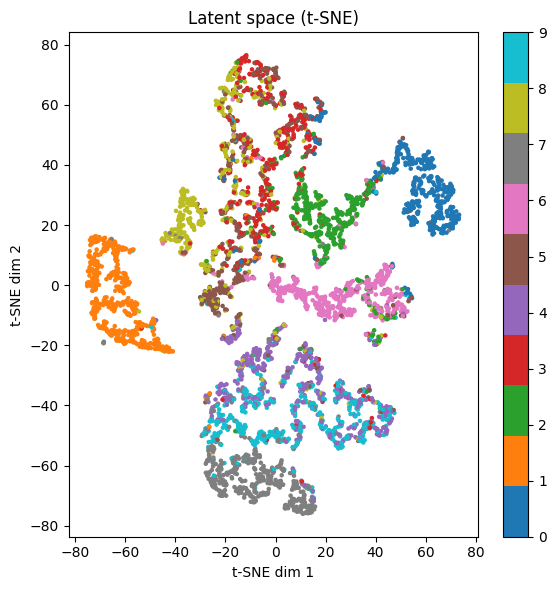

In [8]:
plot_latent_space_tsne(
    model=model,      # np. β = 1
    loader=train_loader,
    device=device,
    perplexity=30
)

## Task 3: Implementing the β-VAE Loss

In the standard Variational Autoencoder (VAE), the training objective is based on
the Evidence Lower Bound (ELBO):

$
L(x;\boldsymbol{\phi},\mathbf{w})
=
\mathbb{E}_{z \sim q_\phi(z \mid x)}
\big[
\log p(x \mid z, \mathbf{w})
\big]
-
\mathrm{KL}\big(q_\phi(z \mid x)\,\|\,p(z)\big).
$

The β-VAE is a modification of this objective, in which the regularization term
is weighted by a positive scalar parameter β:

$
L_{\beta}(x;\boldsymbol{\phi},\mathbf{w})
=
\mathbb{E}_{z \sim q_\phi(z \mid x)}
\big[
\log p(x \mid z, \mathbf{w})
\big]
-
\beta\,\mathrm{KL}\big(q_\phi(z \mid x)\,\|\,p(z)\big).
$

After implementation compare method with diffrent betas for example beta=1, beta=0.1, beta= 10

---

### Objective

Your task is to implement a loss function corresponding to the **negative
β-ELBO**, which is minimized during training. After implementation, please run the code to evaluate the quality of the latent space representation


In [15]:
def beta_vae_loss(x, x_hat, mu, logvar, beta):
    # Reconstruction loss (Bernoulli likelihood
    # TODO
    loss, recon_loss, kl = elbo_loss(x, x_hat, mu, logvar)

    return recon_loss + beta * kl, recon_loss, kl



In [16]:
def train_vae(beta, epochs=10, latent_dim=2, device="cpu"):
    model = VAE(latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        total_recon = 0
        total_kl = 0

        for x, _ in train_loader:
            x = x.view(-1, 28 * 28).to(device)

            optimizer.zero_grad()
            x_hat, mu, logvar = model(x)
            loss, recon, kl = beta_vae_loss(x, x_hat, mu, logvar, beta)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

        print(
            f"β={beta} | Epoch {epoch+1} | "
            f"Loss: {total_loss:.0f} | "
            f"Recon: {total_recon:.0f} | "
            f"KL: {total_kl:.0f}"
        )

    return model

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

betas = [0.1, 1, 5, 10]
models = {}

for beta in betas:
    print(f"\nTraining β-VAE with β = {beta}")
    models[beta] = train_vae(beta, epochs=20, device=device)


Training β-VAE with β = 0.1
β=0.1 | Epoch 1 | Loss: 11055384 | Recon: 10974589 | KL: 807948
β=0.1 | Epoch 2 | Loss: 9670298 | Recon: 9592873 | KL: 774254
β=0.1 | Epoch 3 | Loss: 9391302 | Recon: 9316636 | KL: 746658
β=0.1 | Epoch 4 | Loss: 9226992 | Recon: 9153159 | KL: 738328
β=0.1 | Epoch 5 | Loss: 9109864 | Recon: 9036462 | KL: 734020
β=0.1 | Epoch 6 | Loss: 9030021 | Recon: 8956665 | KL: 733564


KeyboardInterrupt: 

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

def plot_latent_space_tsne(
    model,
    loader,
    device="cpu",
    perplexity=30,
    n_samples=5000,
    random_state=42
):
    model.eval()
    zs = []
    ys = []

    with torch.no_grad():
        for x, y in loader:
            x = x.view(-1, 28 * 28).to(device)
            mu, _ = model.encode(x)
            zs.append(mu.cpu())
            ys.append(y)

            if sum(z.shape[0] for z in zs) >= n_samples:
                break

    z = torch.cat(zs)[:n_samples].numpy()
    y = torch.cat(ys)[:n_samples].numpy()

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )

    z_tsne = tsne.fit_transform(z)

    plt.figure(figsize=(6, 6))
    plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=y, s=5, cmap="tab10")
    plt.colorbar()
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.title("Latent space (t-SNE)")
    plt.tight_layout()
    plt.show()


In [ ]:
plot_latent_space_tsne(
    model=models[1],      # np. β = 1
    loader=train_loader,
    device=device,
    perplexity=30
)

In [ ]:
plot_latent_space_tsne(
    model=models[10],      # np. β = 10
    loader=train_loader,
    device=device,
    perplexity=30
)

In [ ]:
plot_latent_space_tsne(
    model=models[0.1],      # np. β = 0.1
    loader=train_loader,
    device=device,
    perplexity=30
)